# <center> Credit Card Financial Analytics </center>



## Project Overview

### Business Problem
The objective of this project is to analyze credit card revenue drivers, customer spending behavior, and delinquency exposure to provide actionable insights that optimize portfolio profitability and mitigate risk.

### Tools & Technologies
* Python
* Pandas
* NumPy
* MySQL
* Power BI
* CSV

## 1. Import Libraries

We import the Python libraries required for data wrangling, cleaning, and tabular data analysis.

In [5]:
import pandas as pd
import numpy as np
import os

## 2. Load Dataset

The raw customer and credit card datasets (both master and incremental batches) are loaded into Pandas DataFrames for analysis and data cleaning.

In [6]:
data_dir = r"C:\Users\Admin\OneDrive\Desktop\Portfolio Projects\Project 2\Data csv file uncleaned"

df_cust = pd.read_csv(os.path.join(data_dir, "customer.csv"))
df_cust_add = pd.read_csv(os.path.join(data_dir, "cust_add.csv"))
df_cc = pd.read_csv(os.path.join(data_dir, "credit_card.csv"))
df_cc_add = pd.read_csv(os.path.join(data_dir, "cc_add.csv"))

## 3. Initial Data Exploration & Schema Alignment

Before cleaning the data, we examine the structure and standardize all column names to a consistent lowercase `snake_case` format for seamless integration with MySQL. We also align any mismatched columns between the master and incremental files.

In [8]:
# Standardize all column names to lowercase with underscores (MySQL best practice)
for df in [df_cust, df_cust_add, df_cc, df_cc_add]:
    df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# Fix column mismatch: rename 'total_trans_vol' to 'total_trans_ct' in the master credit card data
if 'total_trans_vol' in df_cc.columns:
    df_cc = df_cc.rename(columns={'total_trans_vol': 'total_trans_ct'})

# Check the structure (rows and columns) of the datasets
print("Customer Data Shape:", df_cust.shape)
print("Customer Incremental Data Shape:", df_cust_add.shape)
print("Credit Card Data Shape:", df_cc.shape)
print("Credit Card Incremental Data Shape:", df_cc_add.shape)

# Show the standardized columns to verify 100% consistency
print("\nStandardized Customer Columns:\n", df_cust.columns.tolist())
print("\nStandardized Credit Card Columns:\n", df_cc.columns.tolist())

Customer Data Shape: (10108, 15)
Customer Incremental Data Shape: (185, 15)
Credit Card Data Shape: (10108, 18)
Credit Card Incremental Data Shape: (185, 18)

Standardized Customer Columns:
 ['client_num', 'customer_age', 'gender', 'dependent_count', 'education_level', 'marital_status', 'state_cd', 'zipcode', 'car_owner', 'house_owner', 'personal_loan', 'contact', 'customer_job', 'income', 'cust_satisfaction_score']

Standardized Credit Card Columns:
 ['client_num', 'card_category', 'annual_fees', 'activation_30_days', 'customer_acq_cost', 'week_start_date', 'week_num', 'qtr', 'current_year', 'credit_limit', 'total_revolving_bal', 'total_trans_amt', 'total_trans_ct', 'avg_utilization_ratio', 'use_chip', 'exp_type', 'interest_earned', 'delinquent_acc']


## 4. Data Cleaning

The dataset is cleaned to ensure that the data is consistent, accurate, and suitable for our SQL database and final analysis.

### 4.1 Union Datasets

We append the incremental data batches (Week 53) to the master datasets to create a single, unified view of our customers and their credit card usage.

In [9]:
# Union the customer master and incremental datasets
df_customer = pd.concat([df_cust, df_cust_add], ignore_index=True)

# Union the credit card master and incremental datasets
df_credit_card = pd.concat([df_cc, df_cc_add], ignore_index=True)

print("Unified Customer Records:", len(df_customer))
print("Unified Credit Card Records:", len(df_credit_card))

Unified Customer Records: 10293
Unified Credit Card Records: 10293


### 4.2 Remove Duplicate Records

We identify and remove exact duplicate records based on the primary key (`client_num`) to ensure each customer and their transactions are represented only once.

In [11]:
# Check for duplicates before removing
print("Customer duplicates before:", df_customer.duplicated(subset=['client_num']).sum())
print("Credit Card duplicates before:", df_credit_card.duplicated(subset=['client_num']).sum())

# Drop duplicates keeping the first occurrence
df_customer = df_customer.drop_duplicates(subset=['client_num'], keep='first')
df_credit_card = df_credit_card.drop_duplicates(subset=['client_num'], keep='first')

# Verify shapes after removing duplicates
print("\nCustomer data shape after deduplication:", df_customer.shape)
print("Credit Card data shape after deduplication:", df_credit_card.shape)

Customer duplicates before: 0
Credit Card duplicates before: 0

Customer data shape after deduplication: (10293, 15)
Credit Card data shape after deduplication: (10293, 18)


### 4.3 Handle Missing Values

We check for any null or missing values across both datasets. If missing values are found, we decide whether to drop or impute them based on their impact.

In [13]:
# Check for missing values in the Customer dataset
print("Missing values in Customer data:\n", df_customer.isnull().sum())

# Check for missing values in the Credit Card dataset
print("\nMissing values in Credit Card data:\n", df_credit_card.isnull().sum())

Missing values in Customer data:
 client_num                 0
customer_age               0
gender                     0
dependent_count            0
education_level            0
marital_status             0
state_cd                   0
zipcode                    0
car_owner                  0
house_owner                0
personal_loan              0
contact                    0
customer_job               0
income                     0
cust_satisfaction_score    0
dtype: int64

Missing values in Credit Card data:
 client_num               0
card_category            0
annual_fees              0
activation_30_days       0
customer_acq_cost        0
week_start_date          0
week_num                 0
qtr                      0
current_year             0
credit_limit             0
total_revolving_bal      0
total_trans_amt          0
total_trans_ct           0
avg_utilization_ratio    0
use_chip                 0
exp_type                 0
interest_earned          0
delinquent_acc       

### 4.4 Data Formatting & Standardization

We format text columns (stripping whitespace) to ensure consistency. We also validate the date column and format it as `DD-MM-YYYY` to align with front-end reporting and business communication standards.

In [14]:
# 1. Clean categorical text columns (strip leading/trailing whitespaces)
cat_cust_cols = df_customer.select_dtypes(include='object').columns
for col in cat_cust_cols:
    df_customer[col] = df_customer[col].astype(str).str.strip().str.title()

cat_cc_cols = df_credit_card.select_dtypes(include='object').columns
for col in cat_cc_cols:
    if col != 'week_start_date': # We handle dates separately
        df_credit_card[col] = df_credit_card[col].astype(str).str.strip()

# 2. Parse dates to ensure validity, then explicitly format as DD-MM-YYYY string
df_credit_card['week_start_date'] = pd.to_datetime(
    df_credit_card['week_start_date'], 
    format='%d-%m-%Y', 
    errors='coerce'
).dt.strftime('%d-%m-%Y')

# Verify the date formatting
print("Sample of reporting dates (DD-MM-YYYY):")
print(df_credit_card['week_start_date'].head())

# 3. Ensure numerical columns are properly cast (float)
df_credit_card['credit_limit'] = df_credit_card['credit_limit'].astype(float)
df_credit_card['avg_utilization_ratio'] = df_credit_card['avg_utilization_ratio'].astype(float)
df_credit_card['interest_earned'] = df_credit_card['interest_earned'].astype(float)

Sample of reporting dates (DD-MM-YYYY):
0    01-01-2023
1    01-01-2023
2    01-01-2023
3    01-01-2023
4    01-01-2023
Name: week_start_date, dtype: object


## 5. Exploratory Data Analysis (EDA) & Visualizations

We merge the customer demographic and credit card datasets to analyze risk exposure, spending behavior, and customer segment profiles.

In [17]:
import matplotlib.pyplot as plt

# Merge cleaned customer and credit card tables
df_portfolio = pd.merge(df_customer, df_credit_card, on='client_num', how='inner')

# Calculate Net Revenue (Annual Fees + Interest Earned)
df_portfolio['net_revenue'] = df_portfolio['annual_fees'] + df_portfolio['interest_earned']

print("Portfolio merged successfully with shape:", df_portfolio.shape)

Portfolio merged successfully with shape: (10293, 33)


### 5.1 Delinquency Distribution by Credit Risk Status
We examine the overall distribution of delinquent (`1`) versus performing (`0`) credit card accounts.

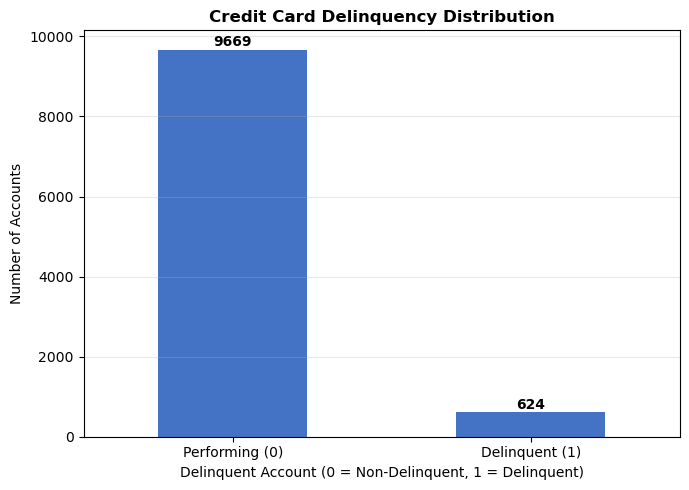

In [19]:
# Delinquency count and percentage table
delinq_counts = df_portfolio['delinquent_acc'].value_counts()

# Bar chart with direct count annotations matching corporate blue styling
ax = delinq_counts.plot(
    kind='bar',
    color='#4472C4',
    figsize=(7, 5)
)

plt.title('Credit Card Delinquency Distribution', fontsize=12, fontweight='bold')
plt.xlabel('Delinquent Account (0 = Non-Delinquent, 1 = Delinquent)')
plt.ylabel('Number of Accounts')
plt.xticks(ticks=[0, 1], labels=['Performing (0)', 'Delinquent (1)'], rotation=0)
plt.grid(axis='y', alpha=0.3)

# Data labels above bars
for i, value in enumerate(delinq_counts):
    ax.text(i, value + 80, str(value), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### 5.2 Delinquency Rate by Customer Income Tier
We bin customer income levels into brackets and calculate the percentage rate of delinquent accounts across each income group.

In [20]:
# Bin income levels
income_bins = [0, 35000, 70000, 100000, 150000, float('inf')]
income_labels = ['<35k', '35k-70k', '70k-100k', '100k-150k', '150k+']

df_portfolio['income_group'] = pd.cut(
    df_portfolio['income'],
    bins=income_bins,
    labels=income_labels
)

# Cross-tabulation normalized by index with bold styling
ct_income = pd.crosstab(
    df_portfolio['income_group'], 
    df_portfolio['delinquent_acc'], 
    normalize='index'
) * 100

# Display styled table with bold headers and index
ct_income.columns.name = 'Delinquent_Acc'
display(ct_income.round(2).style.format('{:.2f}%').set_properties(**{'font-weight': 'bold'}))

Delinquent_Acc,0,1
income_group,,
<35k,93.80%,6.20%
35k-70k,94.41%,5.59%
70k-100k,92.98%,7.02%
100k-150k,94.14%,5.86%
150k+,94.48%,5.52%


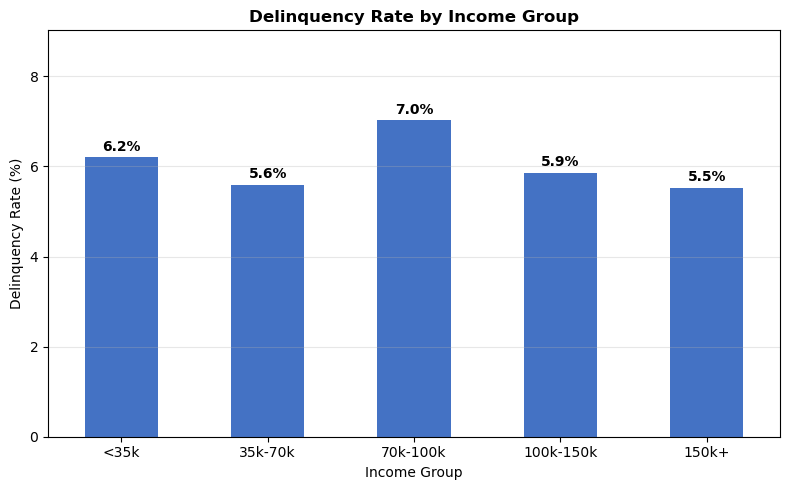

In [21]:
# Bar chart of Delinquency Rate by Income Group
delinq_rate_income = ct_income[1]

ax = delinq_rate_income.plot(
    kind='bar',
    color='#4472C4',
    figsize=(8, 5)
)

plt.title('Delinquency Rate by Income Group', fontsize=12, fontweight='bold')
plt.xlabel('Income Group')
plt.ylabel('Delinquency Rate (%)')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

# Add percentage labels above bars
for i, value in enumerate(delinq_rate_income):
    ax.text(i, value + 0.15, f"{value:.1f}%", ha='center', fontweight='bold')

plt.ylim(0, max(delinq_rate_income) + 2)
plt.tight_layout()
plt.show()

### 5.3 Delinquency Exposure by Personal Loan Status
We analyze whether customers holding existing personal loans exhibit higher delinquency rates.

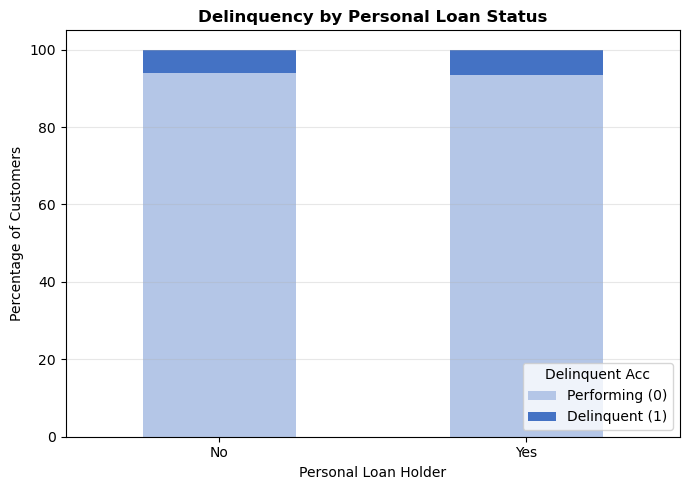

In [22]:
# 100% Normalized Cross-tabulation
ct_loan = pd.crosstab(
    df_portfolio['personal_loan'], 
    df_portfolio['delinquent_acc'], 
    normalize='index'
) * 100

# Render 100% stacked bar chart
ax = ct_loan.plot(
    kind='bar',
    stacked=True,
    color=['#B4C6E7', '#4472C4'],
    figsize=(7, 5)
)

plt.title('Delinquency by Personal Loan Status', fontsize=12, fontweight='bold')
plt.xlabel('Personal Loan Holder')
plt.ylabel('Percentage of Customers')
plt.xticks(rotation=0)
plt.legend(title='Delinquent Acc', labels=['Performing (0)', 'Delinquent (1)'], loc='lower right')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### 5.4 Portfolio Share by Expenditure Category
We examine transaction spend distribution across expenditure categories (`Bills`, `Entertainment`, `Fuel`, `Grocery`, `Food`, `Travel`).

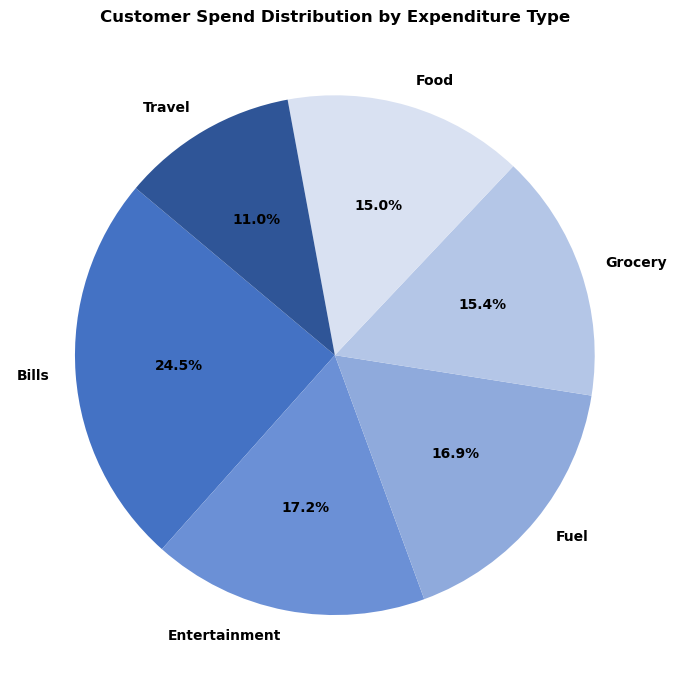

In [24]:
# Aggregate total transaction amount by expenditure type
spend_by_exp = df_portfolio.groupby('exp_type')['total_trans_amt'].sum().sort_values(ascending=False)

# Custom blue palette for pie chart slices
pie_colors = ['#4472C4', '#6B90D6', '#8FAADC', '#B4C6E7', '#D9E1F2', '#2F5597']

plt.figure(figsize=(7, 7))
plt.pie(
    spend_by_exp,
    labels=spend_by_exp.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=pie_colors,
    textprops={'fontsize': 10, 'weight': 'bold'}
)

plt.title('Customer Spend Distribution by Expenditure Type', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.5 Portfolio Share by Card Tier
We evaluate customer portfolio distribution across Card Tiers (`Blue`, `Silver`, `Gold`, `Platinum`).

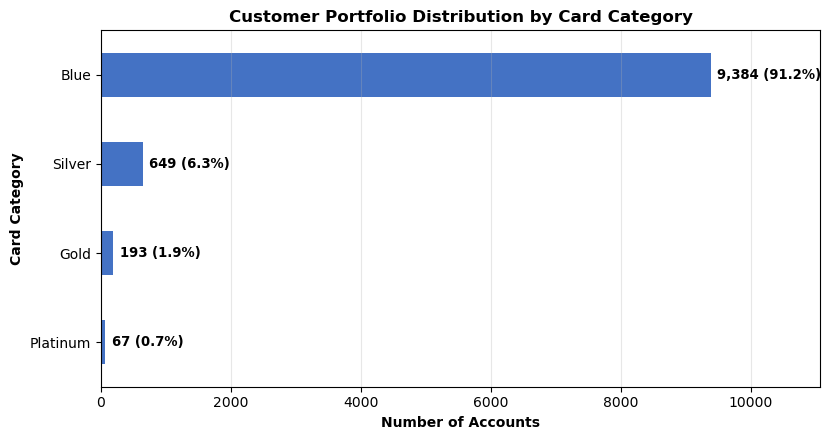

In [27]:
# Aggregate card counts and sort ascending for clean horizontal plotting
card_counts = df_portfolio['card_category'].value_counts().sort_values()
total_cards = len(df_portfolio)

plt.figure(figsize=(8.5, 4.5))
ax = card_counts.plot(
    kind='barh',
    color='#4472C4'
)

plt.title('Customer Portfolio Distribution by Card Category', fontsize=12, fontweight='bold')
plt.xlabel('Number of Accounts', fontsize=10, fontweight='bold')
plt.ylabel('Card Category', fontsize=10, fontweight='bold')
plt.grid(axis='x', alpha=0.3)

# Add exact count and percentage labels next to each bar
for i, value in enumerate(card_counts):
    pct = (value / total_cards) * 100
    ax.text(value + 100, i, f"{value:,} ({pct:.1f}%)", va='center', fontweight='bold', fontsize=9.5)

# Expand x-limit slightly so labels don't get clipped
plt.xlim(0, max(card_counts) * 1.18)
plt.tight_layout()
plt.show()

## 6. Export Cleaned Datasets for MySQL Workbench

The datasets are fully cleaned, validated, deduplicated, and formatted. We export the two tables into clean CSV files:
1. `cleaned_customer.csv` (Dimension table containing customer demographics)
2. `cleaned_credit_card.csv` (Fact table containing credit card operational and transaction metrics)

In [31]:
import os

# Export both datasets without the index column
df_customer.to_csv('customer_churn_cleaned.csv', index=False)
df_credit_card.to_csv('customer_churn_cleaned.csv', index=False)